## Assignment #2

This assignment has three parts.

In the first part, you will implement Principle Components Analysis (from scratch) and use it to reduce the dimensionality of a dataset from 500 different measures, down to two.

In the second part, you will implement K-Means (from scratch) and use it to perform clustering on the dataset dividing the data into a series of clusters.


In the second part you will implement a mulitclass classification system to classify the data in the provided dataset into seven classes.

### Mark-scheme
- Part 1 = 15 marks
- Part 2 = 35 marks
- Part 3 = 50 marks

-------------------------------------------------------------------------------------------------------------

## Part 1: Principle Components Analysis (PCA)
Here you will use the data provided in the "Dataset1.csv" file.

Before clustering the data, you will implement PCA to reduce the dimensionality from 500 to 2. This way, we can see the results of the clustering on an easy to understand 2-dimensional graph.

#### 1.1 Load the Data
Populate the function below to load the data from the requested file.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


In [ ]:
# Load "Dataset1.csv" file
# Returns X where X is a 1000 by 500 (m=1000 and d=500. d is the number of features)
def load_data(file_name):
    # write your code here
    df = pd.read_csv("Dataset1.csv")
    df=df.dropna()
    X = df.to_numpy()

    return X

Loading the dataset as per your function.

In [ ]:
# ## DO NOT MODIFY ##
# Instruction to load the dataset
X = load_data("Dataset1.csv")

#### 1.2 Preprocess the data (5 marks)
Answer the following question:

**1.a)** Question: What pre-processing method will you use and why?

<font color='yellow'>Write your answer here:</font>
For prerprocessing i have used Standard Scaler which will perform each feature to have a mean of 0 and a standard deviation of 1, which ensures that all features contribute equally to the distance calculations. This helps kmeans to perform better and creates more meaningful clusters.


Populate the function below to perform any pre-processing needed to perform PCA (successfully).

In [ ]:
def pre_process(X):
    # write your code here
    scaler=StandardScaler()
    X=scaler.fit_transform(X)

    return X

#### 1.3 PCA Implementation (10 marks)
Implement PCA to reduce the dimensionality of the input matrix X from its original dimensions to 2.
- 10 marks for a correct manual implementation (you may use numpy functions - except PCA of course)
- 5 marks for a library call

In [ ]:
# Perform Principle components analysis on X, returning a 2-dimension output
# input:
# - X:    High dimensional dataset
# output:
# - X_2d: Two dimensional dataset
def my_PCA(X):
    # write your code here
    pca=PCA(n_components=2)
    X_2d=pca.fit_transform(X)

    return X_2d

(999, 2)


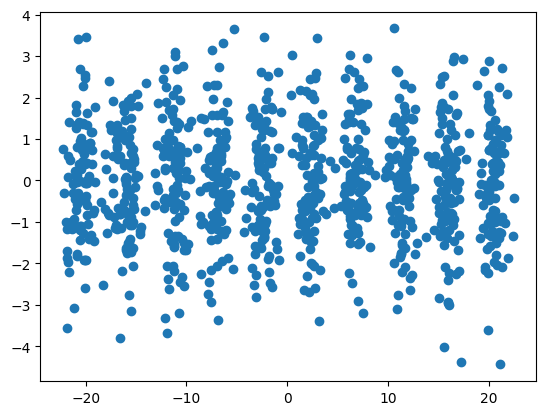

In [ ]:
# ## DO NOT MODIFY ##
# Calling all of the created functions and plotting a 2D graph of the new 'data points'
X = pre_process(X)
X_2d = my_PCA(X)
# check out the shape and scatter plot the points
print(X_2d.shape)
plt.scatter(X_2d[:,0], X_2d[:,1])

## Part 2: K-means

#### 2.1 Initialisation (5 marks)
Implement a function which randomly initialises centroids. Please note, the data is one of the input variables for a reason.

In [ ]:
# input:
# - k: number of centers
# - X: the data
# output:
# - centroids is a k by 2
def initialise_centroids(X,k):
    # Write your code here
    centroids=X[np.random.choice(X.shape[0],k,replace=False)]

    return centroids

Code to call and display ten randomly created centroids. If you get ten rainbow dots, you are on the right track.

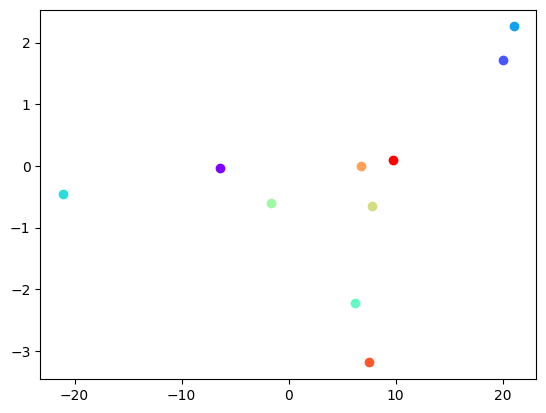

In [ ]:
# ## DO NOT MODIFY ##
centroids = initialise_centroids(X_2d, 10)

# the code below will plot the centroids
colors = iter(plt.cm.rainbow(np.linspace(0, 1, len(centroids))))
for c in centroids:
    plt.scatter(c[0], c[1], color=next(colors))

#### 2.2 Assigning Points to Centroids (5 marks)
Implement a function that takes the matrix X and a set of centroids and assigns each point in X to one of the provided centroids.

In [ ]:
from scipy.spatial.distance import cdist
# input:
# - X is a m by 2 point
# - centroids is a k by 2 , the center of k clusters.
# output:
# - cluster_assignments is an m by 1 vector. the id of the cluster for each point in X
def assign(X,centroids):
    # Write your code here
    cluster_assignments=np.argmin(cdist(X,centroids),axis=1)
    return cluster_assignments

Code to assign each of the points from the post-PCA data a relevant centroid.

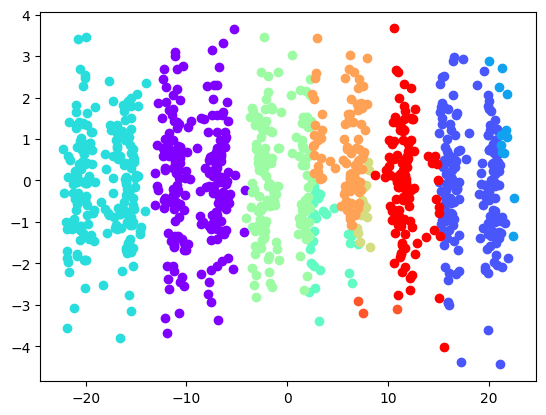

In [ ]:
# ## DO NOT MODIFY ##
cluster_assignments = assign(X_2d, centroids)

# the code below will plot the points color-coded according to their cluster
colors = iter(plt.cm.rainbow(np.linspace(0, 1, len(centroids))))
for k in np.unique(cluster_assignments):
    plt.scatter(X_2d[cluster_assignments==k,0], X_2d[cluster_assignments==k,1], color=next(colors))

#### 2.3 K-Means Cost Function (5 marks)
Implement a function to compute the value of a cost function given a set of centroids and assignments

In [ ]:
# input:
# - X is a m by 2 point
# - centroids is a k by 2 , the center of k clusters.
# - cluster_assignments is an m by 1 vector. the id of the cluster for each point in X
# output:
# - cost is the overall 'cost' of the current assignments

def cost(X, cluster_assignments, centroids):

    # Write your code here
  cost = 0
  for i in range(X.shape[0]):

      assigned_centroid = centroids[cluster_assignments[i]]
      cost += np.linalg.norm(X[i] - assigned_centroid) ** 2
  return cost

Code (assuming 10 centroids) which assigns each cluster and generates the equivalent cost.

In [ ]:
# ## DO NOT MODIFY
k=10
centroids = initialise_centroids(X_2d, k)
cluster_assignments = assign(X_2d, centroids)
c = cost(X_2d,cluster_assignments,centroids)
print(c)

31457.01248992346


#### 2.4 Putting it all together (20 marks)
Implement a function to perform the k-means algorithm using the functions you implemented above.

- 20 marks for a correct manual implementation (you may use numpy functions - except PCA of course)
- 5 marks for a library call

In [ ]:
# input:
# - X is a m by 2 list of points
# - k is the required number of centroids
# - num_of_iterations is the number of times the k-means algorithm will run before 'giving up'
# output:
# - cluster_assignments is a m x 1 for each point in X, which cluster it belongs to
# - centroids is a k x 2 matrix detailing the centroids of each cluster
def My_Kmeans(X,k,num_of_iterations):
    # Write your code here
    centroids=initialise_centroids(X,k)
    for i in range(num_of_iterations):
        cluster_assignments=assign(X,centroids)
    return cluster_assignments, centroids


Code to run and test the final algorithm with 10 clusters, 1000 iterations. If you get ten blobs each of which is a different colour, you are on the right track.

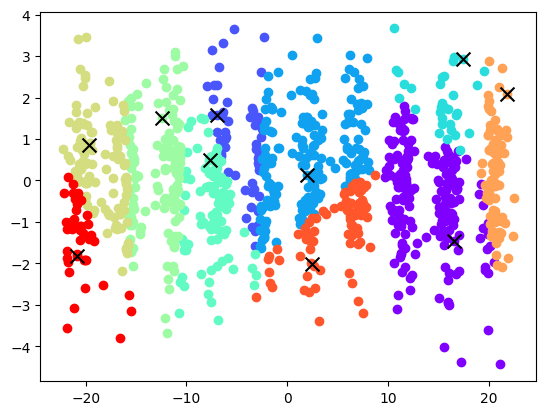

In [ ]:
k = 10
centroids = []
cluster_assignments , centroids = My_Kmeans(X_2d,k,1000)

# the code below will plot the points color-coded according to their cluster
colors = iter(plt.cm.rainbow(np.linspace(0, 1, k)))
for k in np.unique(cluster_assignments):
    plt.scatter(X_2d[cluster_assignments==k,0], X_2d[cluster_assignments==k,1], color=next(colors))
    plt.scatter(centroids[k][0],centroids[k][1],marker="x",s=100,c='k')

<ipython-input-26-d58d6333b3ec>:7: DeprecationWarning: loadtxt(): Parsing an integer via a float is deprecated.  To avoid this warning, you can:
    * make sure the original data is stored as integers.
    * use the `converters=` keyword argument.  If you only use
      NumPy 1.23 or later, `converters=float` will normally work.
    * Use `np.loadtxt(...).astype(np.int64)` parsing the file as
      floating point and then convert it.  (On all NumPy versions.)
  (Deprecated NumPy 1.23)
  cluster_assignments_true = np.loadtxt("True_clusters_IDs.csv", delimiter=",", dtype=int)


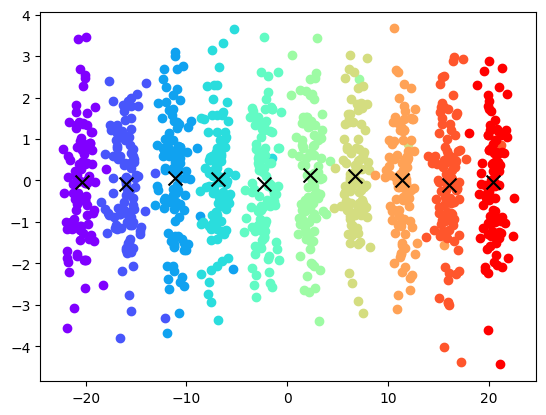

In [ ]:
k = 10
cluster_assignments_true = np.loadtxt("True_clusters_IDs.csv", delimiter=",", dtype=int)
cluster_assignments_true = cluster_assignments_true.reshape(-1)
cluster_assignments_true = cluster_assignments_true[:X_2d.shape[0]]

centroids = []
for idx in range(k):
    temp_cent = X_2d[cluster_assignments_true==idx].mean(axis=0)
    centroids.append(temp_cent)

colors = iter(plt.cm.rainbow(np.linspace(0, 1, k)))
for k in range(k):

    plt.scatter(X_2d[cluster_assignments_true==k,0], X_2d[cluster_assignments_true==k,1], color=next(colors))
    plt.scatter(centroids[k][0],centroids[k][1],marker="x",s=100,c='k')

Clustering according to the data's true clusters.

# Part 3 (50 Marks)

You will use the data provided in the **"Dataset2.xlxs"** file in Part 3 of the assignment. The dataset consists of 13611 samples belonging to seven different classes. Each sample has 16 features.

* Objective: Using the provided dataset, develop a seven class classification method.

* Evaluation Criteria: Your points will be based on the final **average accuracy** achieved by your method in a **10-fold cross validation** framework.

    * 25 marks for achieving a classification accuracy above 82% and upto 87.92%         
    * 40 marks for achieving a classification accuracy above 87.92% and up to 90.0%  
    * 45 marks for achieving a classification accuracy above 90.0% and upto 93.13%
    * 50 marks for achieving a classification accuracy above 93.13%.     

* You have the freedom to employ any pre-processing, classifiers, and
post-processing pipeline that you find applicable. Feel free to experiment with
a wide range of machine learning methods to improve the performance of your system.

* Your claims and results must be reproducable.

* To ensure the reproducibility of your results and claims, it is essential that you save both your trained models, hyperparameter specifications,  and the random seeds used throughout your experiments. Saving your models will allow reproducing the achieved accuracy, and recording the random seeds will help validate any randomness in your processes.

In [37]:
import pandas as pd
import lightgbm as lgb
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt


data = pd.read_excel('Dataset2.xlsx', header=None)
column_names = [f'Feature{i+1}' for i in range(16)] + ['Target']
data.columns = column_names

X = data.drop('Target', axis=1)
y = data['Target']

X.fillna(X.mean(), inplace=True)
scaler = RobustScaler()

X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled)


X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42, stratify=y)


lgbm = lgb.LGBMClassifier(random_state=42)
lgbm.fit(X_train, y_train)

y_pred = lgbm.predict(X_test)

final_accuracy = accuracy_score(y_test, y_pred)
print(f"Final accuracy on test set: {final_accuracy:.4f}")


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001761 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2550
[LightGBM] [Info] Number of data points in the train set: 10888, number of used features: 10
[LightGBM] [Info] Start training from score -1.904618
[LightGBM] [Info] Start training from score -2.332227
[LightGBM] [Info] Start training from score -3.259935
[LightGBM] [Info] Start training from score -2.122225
[LightGBM] [Info] Start training from score -1.954581
[LightGBM] [Info] Start training from score -1.641447
[LightGBM] [Info] Start training from score -1.344914
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further s

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Final accuracy on test set: 0.9288
